# Parte 1: Pre-procesado, Limpieza y Recodificación

Este notebook aborda la primera fase del proyecto: transformar los datos en bruto para asegurar su calidad y fiabilidad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
file_path = '../data/processed/rita-2012-2022.xlsx'
df = pd.read_excel(file_path)

# Mostrar las primeras filas
print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,IDPTE,PTESXN,FECHA_DIAGNÓSTICO,EDAD_DIAGNÓSTICO,TOPOGRAFÍA,TOPOGRAFÍA_N,MORFOLOGÍA,MORFOLOGÍA_N,COMPORTAMIENTO,COMPORTAMIENTO_N,METODO_DIAGNÓSTICO,METODO_DIAGNÓSTICO_N
0,1402,Hombre,2012-04-30,69,C17.0,(C17.0)-Duodeno,8140.0,"(8140)-Adenocarcinoma, SAI",3,"Maligno, Sitio primario",8,Histología de tumor primario
1,28769,Hombre,2014-12-16,81,C16.9,"(C16.9)-Gástrico, SAI",8144.0,"(8144)-Adenocarcinoma, tipo intestinal (C16._)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...
2,52073,Mujer,2016-05-15,66,C50.9,"(C50.9)-Mama, SAI",8500.0,"(8500)-Carcinoma ductal infiltrante, SAI (C50._)",3,"Maligno, Sitio primario",8,Histología de tumor primario
3,28576,Mujer,2014-09-03,59,C54.1,(C54.1)-Endometrio,8930.0,"(8930)-Sarcoma endometrial, SAI (C54.1)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...
4,61923,Mujer,2016-04-25,61,C56.9,(C56.9)-Ovario,8460.0,(8460)-Cistadenocarcinoma seroso papilar (C56.9),3,"Maligno, Sitio primario",8,Histología de tumor primario


## 1.1 Limpieza de Columnas (CRUD)
Identificamos que algunas columnas tienen espacios adicionales al final de su nombre.

In [2]:
# Limpiar nombres de columnas
df.columns = df.columns.str.strip()
print("Columnas limpias:", df.columns.tolist())

Columnas limpias: ['IDPTE', 'PTESXN', 'FECHA_DIAGNÓSTICO', 'EDAD_DIAGNÓSTICO', 'TOPOGRAFÍA', 'TOPOGRAFÍA_N', 'MORFOLOGÍA', 'MORFOLOGÍA_N', 'COMPORTAMIENTO', 'COMPORTAMIENTO_N', 'METODO_DIAGNÓSTICO', 'METODO_DIAGNÓSTICO_N']


## 1.2 Identificación y Tratamiento de Valores Ausentes
Buscamos celdas vacías o nulas.

In [3]:
# Contar valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Si existieran nulos, podríamos imputar o eliminar:
# df['EDAD_DIAGNÓSTICO'] = df['EDAD_DIAGNÓSTICO'].fillna(df['EDAD_DIAGNÓSTICO'].mean())
# df.dropna(inplace=True)

Valores nulos por columna:
IDPTE                     0
PTESXN                    0
FECHA_DIAGNÓSTICO         0
EDAD_DIAGNÓSTICO          0
TOPOGRAFÍA               17
TOPOGRAFÍA_N              0
MORFOLOGÍA              240
MORFOLOGÍA_N              0
COMPORTAMIENTO            0
COMPORTAMIENTO_N          0
METODO_DIAGNÓSTICO        0
METODO_DIAGNÓSTICO_N      0
dtype: int64


## 1.3 Detección de Datos Atípicos (Outliers)
Usaremos el método del Rango Intercuartílico (IQR) para la edad.

Número de outliers detectados en Edad: 1


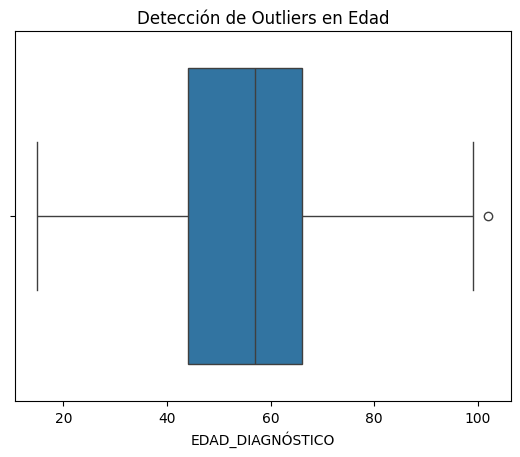

In [4]:
Q1 = df['EDAD_DIAGNÓSTICO'].quantile(0.25)
Q3 = df['EDAD_DIAGNÓSTICO'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['EDAD_DIAGNÓSTICO'] < limite_inferior) | (df['EDAD_DIAGNÓSTICO'] > limite_superior)]
print(f"Número de outliers detectados en Edad: {len(outliers)}")

# Visualizar
sns.boxplot(x=df['EDAD_DIAGNÓSTICO'])
plt.title('Detección de Outliers en Edad')
plt.show()

## 1.4 Recodificación y Caseteo
Convertiremos la variable 'PTESXN' (Sexo) a un formato numérico.

In [5]:
# Diccionario de recodificación
sexo_map = {'Hombre': 0, 'Mujer': 1}
df['SEXO_NUM'] = df['PTESXN'].map(sexo_map)

print("Nueva columna SEXO_NUM (0=Hombre, 1=Mujer):")
print(df[['PTESXN', 'SEXO_NUM']].head())

Nueva columna SEXO_NUM (0=Hombre, 1=Mujer):
   PTESXN  SEXO_NUM
0  Hombre         0
1  Hombre         0
2   Mujer         1
3   Mujer         1
4   Mujer         1


In [6]:
# Guardar el dataset limpio para la siguiente fase
df.to_csv('../data/processed/rita_limpio.csv', index=False)
print("Dataset guardado como 'data/processed/rita_limpio.csv'")

Dataset guardado como 'data/processed/rita_limpio.csv'
